In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()


In [2]:
# Data Cleaning -- Null Value Replaced with Median Salary
df_raw = df.copy()
median_average = df_raw[['salary_hour_avg',
  'salary_year_avg']].median()
median_average

df_na_cleaned = df_raw.copy()
df_na_cleaned[['salary_hour_avg',
  'salary_year_avg']] = df_raw[['salary_hour_avg',
  'salary_year_avg']].fillna(median_average)
df_na_cleaned = df_na_cleaned.dropna(subset = ['job_type_skills'])
df_na_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 668704 entries, 1 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        668704 non-null  object 
 1   job_title              668704 non-null  object 
 2   job_location           667775 non-null  object 
 3   job_via                668696 non-null  object 
 4   job_schedule_type      658121 non-null  object 
 5   job_work_from_home     668704 non-null  bool   
 6   search_location        668704 non-null  object 
 7   job_posted_date        668704 non-null  object 
 8   job_no_degree_mention  668704 non-null  bool   
 9   job_health_insurance   668704 non-null  bool   
 10  job_country            668665 non-null  object 
 11  salary_rate            29801 non-null   object 
 12  salary_year_avg        668704 non-null  float64
 13  salary_hour_avg        668704 non-null  float64
 14  company_name           668696 non-nu

In [3]:
#Unpacking String into Lists & Parsing:
df_expanded = df_na_cleaned.copy()
df_expanded['job_skills'] = df_expanded['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)
df_expanded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,115000.0,45.98,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,115000.0,45.98,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,115000.0,45.98,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,115000.0,45.98,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,115000.0,45.98,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,115000.0,45.98,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,115000.0,45.98,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [4]:
# cleaning -- dates
df_expanded['job_posted_date'] = pd.to_datetime(df_expanded['job_posted_date'])
df_expanded


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,115000.0,45.98,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,115000.0,45.98,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,115000.0,45.98,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,115000.0,45.98,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,115000.0,45.98,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,115000.0,45.98,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,115000.0,45.98,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


EDA: INDIA Data Jobs Analysis

In [5]:
df_india_raw = df_expanded[df_expanded['job_country'] == 'India']
df_india_raw

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,"[powershell, python, sql, mysql, sql server, d...","{'cloud': ['databricks', 'azure'], 'databases'..."
19,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Indeed,Full-time,False,India,2023-04-26 13:20:12,False,False,India,None,115000.0,45.98,Bitwise Solutions,"[r, sql, python, scala, java, c++, hadoop, tab...","{'analyst_tools': ['tableau'], 'libraries': ['..."
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,None,115000.0,45.98,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'..."
42,Senior Data Engineer,"Senior Data Engineer(Python)-1563,1637&1633","Chennai, Tamil Nadu, India",via HR Software For Growing Businesses | Fresh...,Full-time,False,India,2023-11-10 13:30:41,True,False,India,None,115000.0,45.98,CESIT,"[python, sql, aws, pyspark, docker, jira]","{'async': ['jira'], 'cloud': ['aws'], 'librari..."
80,Data Engineer,Director - Enterprise Architecture and Data En...,"Chennai, Tamil Nadu, India",via Indeed,Full-time,False,India,2023-05-11 13:20:16,False,False,India,None,115000.0,45.98,Ford Motor Company,"[gcp, graphql, kubernetes]","{'cloud': ['gcp'], 'libraries': ['graphql'], '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785695,Data Engineer,AWS Data Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-05 06:35:07,False,False,India,None,115000.0,45.98,LatentView Analytics,"[python, sql, scala, aws, snowflake, databrick...","{'cloud': ['aws', 'snowflake', 'databricks'], ..."
785697,Data Scientist,Data Science Python modelling,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-01-16 06:12:27,False,False,India,None,115000.0,45.98,Live Connections,"[python, sql, r, power bi, tableau, word, exce...","{'analyst_tools': ['power bi', 'tableau', 'wor..."
785712,Data Engineer,India - Collections Analyst II,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Varite India Private Limited,"[excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']}"
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,"[c#, sql]","{'programming': ['c#', 'sql']}"


In [6]:
df_india = df_india_raw.explode('job_skills')
df_india

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,powershell,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,python,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,sql,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,mysql,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,sql server,"{'cloud': ['databricks', 'azure'], 'databases'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785712,Data Engineer,India - Collections Analyst II,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Varite India Private Limited,flow,"{'analyst_tools': ['excel'], 'other': ['flow']}"
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,c#,"{'programming': ['c#', 'sql']}"
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,sql,"{'programming': ['c#', 'sql']}"
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


In [7]:
df_india_skill_counts = df_india.groupby(['job_title_short','job_skills']).size()
df_india_skill_counts = df_india_skill_counts.reset_index(name='skill_count')

df_india_skill_counts.sort_values(by = 'skill_count',ascending = False, inplace = True)
df_india_skill_counts

,job_title_short,job_skills,skill_count
637,Data Engineer,sql,12993
603,Data Engineer,python,11568
807,Data Scientist,python,9248
632,Data Engineer,spark,7157
480,Data Engineer,aws,6993
...,...,...,...
1472,Senior Data Scientist,svn,1
998,Machine Learning Engineer,svn,1
138,Business Analyst,twilio,1
835,Data Scientist,solidity,1


In [8]:
df_india_skill_counts.groupby(['job_title_short']).size().head(3)

job_title_short
Business Analyst    154
Cloud Engineer      131
Data Analyst        181
dtype: int64

In [10]:
df_job_india_count = df_india_raw.groupby(['job_title_short']).size().reset_index()
df_job_india_count.columns = ['job_title_short','jobs_total']

In [11]:
df_perc_india = pd.merge(df_india_skill_counts,df_job_india_count, on = 'job_title_short', how = 'left')
df_perc_india['skills_perc'] = df_perc_india['skill_count']/df_perc_india['jobs_total']*100
df_perc_india

,job_title_short,job_skills,skill_count,jobs_total,skills_perc
0,Data Engineer,sql,12993,17966,72.319938
1,Data Engineer,python,11568,17966,64.388289
2,Data Scientist,python,9248,11504,80.389430
3,Data Engineer,spark,7157,17966,39.836358
4,Data Engineer,aws,6993,17966,38.923522
...,...,...,...,...,...
1684,Senior Data Scientist,svn,1,2221,0.045025
1685,Machine Learning Engineer,svn,1,629,0.158983
1686,Business Analyst,twilio,1,1449,0.069013
1687,Data Scientist,solidity,1,11504,0.008693


In [23]:
target_jobs = df_perc_india.groupby('job_title_short')['jobs_total'].max().sort_values(ascending = False).head(3).index.tolist()
target_jobs

['Data Engineer', 'Data Scientist', 'Data Analyst']

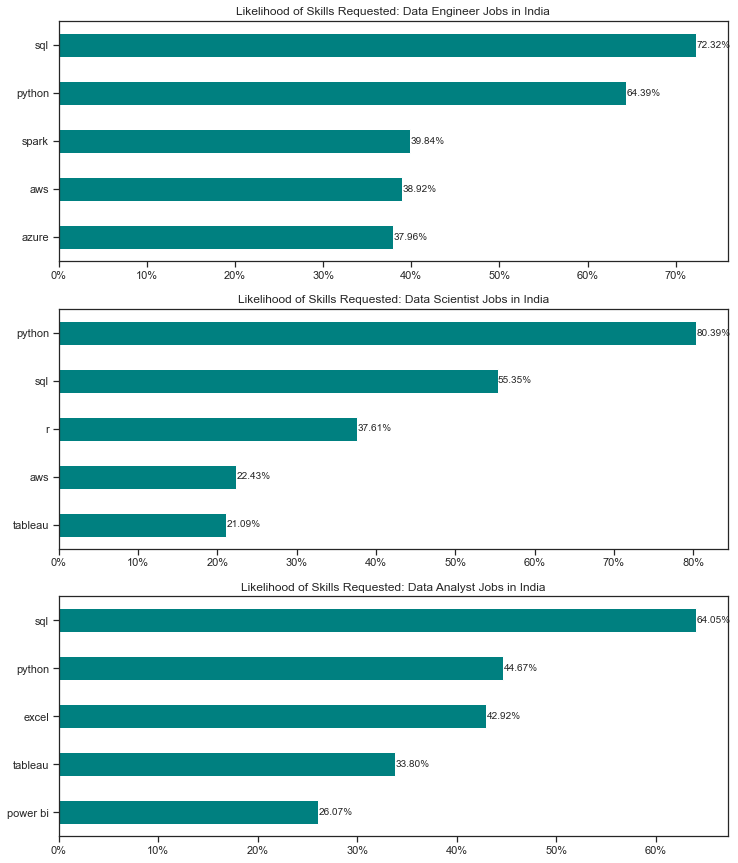

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(3,1, figsize = (12,15))
for i , job in enumerate(target_jobs):
    df_perc_india_targets = df_perc_india[df_perc_india['job_title_short']== job]
    df_top5skills_india_target = df_perc_india_targets.sort_values(by='skills_perc',ascending = False).head(5)
    df_plot_5skills_india_target = df_top5skills_india_target.sort_values(by='skills_perc',ascending = True)
    df_plot_5skills_india_target.plot(
        kind = 'barh',
        color = 'teal',
        y ='skills_perc',
        x = 'job_skills',
        ax = ax[i],
        legend = False,
        title = f'Likelihood of Skills Requested: {job} Jobs in India'
    )
    for index, row in df_plot_5skills_india_target.reset_index().iterrows():
        val = row['skills_perc']
        ax[i].text(x=val + 0.05, y=index, s=f"{val:.2f}%", va='center', fontsize=10)
        
    # Clean up axis metrics once per chart loop spin
    ax[i].set_ylabel("")
    ax[i].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))


In [53]:
df_plots_5skills_india

<AxesSubplot:title={'center':'Likelihood of Skills Requested: Data Analyst Jobs in India'}, ylabel='job_skills'>